# RAG Project

# Data Ingestion Pipeleine: to Vector DB

In [1]:
import os
from langchain_community.document_loaders import PyMuPDFLoader, PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11408\582141364.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader, PyPDFLoader
c:\Users\Lenovo\anaconda3\envs\mla\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
### Read all the pdf's inside the directory

def process_all_pdfs(filepath):
    all_documents = []
    pdf_dir = Path(filepath)
    
    pdf_files = list(pdf_dir.glob('**/*.pdf'))
    
    print(f"Found {len(pdf_files)} PDF files to process...")
    
    for pdf_file in pdf_files:
        print(f"\nProcessing {pdf_file.name}...")
        
        try:
            loader = PyPDFLoader(str(pdf_file))
            documents = loader.load()
            
            # Add source info to meta data
            for doc in documents:
                doc.metadata['source_file'] = pdf_file.name
                doc.metadata['file_type'] = 'pdf'
                
            all_documents.extend(documents)
            print(f" Loaded {len(documents)} pages")
            
        except Exception as e:
            print(f" Error: {e}")
            
    print(f"\nTotal Documents Loaded: {len(all_documents)}")
    return all_documents

all_pdf_documents = process_all_pdfs("../data")

print(all_pdf_documents)
        

Found 4 PDF files to process...

Processing attention.pdf...
 Loaded 15 pages

Processing embedding_qwen.pdf...


Multiple definitions in dictionary at byte 0x8c8 for key /ExtGState
Multiple definitions in dictionary at byte 0x141b for key /ExtGState
Multiple definitions in dictionary at byte 0x2a25 for key /ExtGState
Multiple definitions in dictionary at byte 0x699 for key /ExtGState
Multiple definitions in dictionary at byte 0x14d9 for key /ExtGState
Multiple definitions in dictionary at byte 0x184a for key /ExtGState
Multiple definitions in dictionary at byte 0x21fc for key /ExtGState
Multiple definitions in dictionary at byte 0x2a6f for key /ExtGState
Multiple definitions in dictionary at byte 0x463 for key /ExtGState
Multiple definitions in dictionary at byte 0xdd3 for key /ExtGState
Multiple definitions in dictionary at byte 0x15f3 for key /ExtGState
Multiple definitions in dictionary at byte 0x1d66 for key /ExtGState
Multiple definitions in dictionary at byte 0x22c1 for key /ExtGState
Multiple definitions in dictionary at byte 0x2e79 for key /ExtGState
Multiple definitions in dictionary at 

 Loaded 14 pages

Processing food101.pdf...
 Loaded 16 pages

Processing objectdetection.pdf...
 Loaded 6 pages

Total Documents Loaded: 51
[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '..\\data\\pdf\\attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'source_file': 'attention.pdf', 'file_type': 'pdf'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google

In [3]:
all_pdf_documents

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '..\\data\\pdf\\attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'source_file': 'attention.pdf', 'file_type': 'pdf'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗ †\nUniversity of T

## Chunking

In [4]:
### Text splitting get into chunks

def split_documents(documents, chunk_size=1000, chunk_overlap=200):
    
    """Splitting documents into smaller chunks for better RAG performance"""
     
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""] # "" is empty space
    )
    
    split_docs = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")
    
    # show sample chunk
    if split_docs:
        print(f"\nExample chunk:")
        print(f"Content: {split_docs[0].page_content[:200]}...")
        print(f"Metadata: {split_docs[0].metadata}")
    
    return split_docs


In [5]:
chunks = split_documents(all_pdf_documents)

chunks

Split 51 documents into 205 chunks

Example chunk:
Content: Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
...
Metadata: {'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '..\\data\\pdf\\attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'source_file': 'attention.pdf', 'file_type': 'pdf'}


[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '..\\data\\pdf\\attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'source_file': 'attention.pdf', 'file_type': 'pdf'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗ †\nUniversity of T

## Embedding & VectorDB

In [7]:
### Text to Vector (numeric values)

import numpy as np
from sentence_transformers import SentenceTransformer # Embedding model is inside it
import chromadb # VectorDB
from chromadb.config import Settings
import uuid # VectorDB ထဲထည့်ရင်ထားဖို့ ID
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity # Evaluation Metrics

In [8]:
class EmbeddingManager:
    """Handles document embedding generation using SentenceTransformer"""
    
    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        
        """
        Initialize the embedding manager
        
        Args:
            model_name: HuggingFace model name for sentencce embeddings
        """
        self.model_name = model_name
        self.model = None
        self._load_model()
        
    def _load_model(self):
        """Load the SentenceTransformer model"""
        try:
            print(f"Loading embedding model: {self.model_name}")
            self.model = SentenceTransformer(self.model_name)
            print(f"Model Loaded successfully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")
                  
        except Exception as e:
            print(f"Error loading model {self.model_name}: {e}")
            raise
        
        
    def _generate_embedding(self, texts: List[str]) -> np.array:
        
        """
        Generate embeddings for a list of texts
        
        Args:
            texts: List of text strings to embed
            
        Returns:
            numpy array of embeddings with shape (len(texts), embedding_dim)
        """
        
        if not self.model:
            raise ValueError("Model not loaded")
        
        print(f"Generating embeddings for {len(texts)} texts...")
        embeddings = self.model.encode(texts, show_progress_bar=True)
        print(f"Generated embeddings with shape: {embeddings.shape}")
        return embeddings  

# Initialize embedding manager
embedding_manager = EmbeddingManager()
embedding_manager

Loading embedding model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4103.16it/s]


Model Loaded successfully. Embedding dimension: 384


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11408\1418930267.py:21: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model Loaded successfully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")


### VectorStore

In [9]:
class VectorStore:
    """Manages document embeddings in a ChromaDB vector store"""
    
    def __init__(self, collection_name: str = "pdf_documents", persist_directory: str = "../data/vector_store"):
        """
        Initialize the vector store
        
        Args:
            collection_name: Name of the ChromaDB collection
            persist_directory: Directory to persist the vector store
        """
        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None
        self.collection = None
        self._initialize_store()

    def _initialize_store(self):
        """Initialize ChromaDB client and collection"""
        try:
            # Create persistent ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True)
            self.client = chromadb.PersistentClient(path=self.persist_directory)
            
            # Get or create collection
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={"description": "PDF document embeddings for RAG"}
            )
            print(f"Vector store initialized. Collection: {self.collection_name}")
            print(f"Existing documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error initializing vector store: {e}")
            raise

    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        """
        Add documents and their embeddings to the vector store
        
        Args:
            documents: List of LangChain documents
            embeddings: Corresponding embeddings for the documents
        """
        if len(documents) != len(embeddings):
            raise ValueError("Number of documents must match number of embeddings")
        
        print(f"Adding {len(documents)} documents to vector store...")
        
        # Prepare data for ChromaDB
        ids = []
        metadatas = []
        documents_text = []
        embeddings_list = []
        
        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            # Generate unique ID
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)
            
            # Prepare metadata
            metadata = dict(doc.metadata)
            metadata['doc_index'] = i
            metadata['content_length'] = len(doc.page_content)
            metadatas.append(metadata)
            
            # Document content
            documents_text.append(doc.page_content)
            
            # Embedding
            embeddings_list.append(embedding.tolist())
        
        # Add to collection
        try:
            self.collection.add(
                ids=ids,
                embeddings=embeddings_list,
                metadatas=metadatas,
                documents=documents_text
            )
            print(f"Successfully added {len(documents)} documents to vector store")
            print(f"Total documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise

vectorstore=VectorStore()
vectorstore

Vector store initialized. Collection: pdf_documents
Existing documents in collection: 205


In [11]:
chunks

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '..\\data\\pdf\\attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'source_file': 'attention.pdf', 'file_type': 'pdf'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗ †\nUniversity of T

In [12]:
## Convert text to embeddings

texts = [doc.page_content for doc in chunks]

## Generate the embeddings

embeddings = embedding_manager._generate_embedding(texts)

## Store in the Vector DB

vectorstore.add_documents(chunks, embeddings)

Generating embeddings for 205 texts...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches: 100%|██████████| 7/7 [00:10<00:00,  1.55s/it]


Generated embeddings with shape: (205, 384)
Adding 205 documents to vector store...
Successfully added 205 documents to vector store
Total documents in collection: 410


In [13]:
type(vectorstore)

__main__.VectorStore

In [14]:
vectorstore.collection_name

'pdf_documents'

In [15]:
vectorstore.persist_directory

'../data/vector_store'

---

# Retrieval Pipeline: From VectorStore

In [37]:
class RAGRetriever:
    """Handle query-based retrieval from the vector store"""
    
    
    def __init__(self, vector_store: VectorStore, embedding_manager: EmbeddingManager):
        """Initialize the retriever
        
        Args:
            vector_store:
            embedding_manager
        """
        self.vector_store = vector_store
        self.embedding_manager = embedding_manager
        
    def retrieve(self, query: str, top_k: int = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]:
        """
        Retrieve relevant documents for a query
        
        Args:
            query
            top k
            score_threshold
            
        Returns:
            List of dictionaries containing retrieved documents and metadata"""
            
        print(f"Retrieving documents for query: '{query}'")
        print(f"Top K: {top_k}, Score threshold: {score_threshold}")
        
        # Query Embedding
        query_embedding = self.embedding_manager._generate_embedding([query])[0]
        
        # Search in vector store
        try:
            results = self.vector_store.collection.query(
                query_embeddings=[query_embedding.tolist()],
                n_results = top_k
            )
            
            retrieved_docs = []
            
            if results['documents'] and results['documents'][0]:
                documents = results['documents'][0]
                metadatas = results['metadatas'][0]
                distances = results['distances'][0]
                ids = results['ids'][0]
                
                for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)): 
                    # Convert distance to similarity score (ChromaDB uses cosine similarity) 
                    similarity_score = 1 - distance
                    
                    if similarity_score >= score_threshold:
                        retrieved_docs.append({
                            'id': doc_id,
                            'content': document,
                            'metadata': metadata,
                            'similarity_score': similarity_score,
                            'distance': distance,
                            'rank': i + 1
                        })
                        
                print(f"Retrieved {len(retrieved_docs)} documents (after filtering)")
            else:
                print("No documents found")   
        
            return retrieved_docs
        
        except Exception as e:
            print(f"Error during retrieval: {e}")
            return []                         
        

In [38]:
rag_retriever = RAGRetriever(vectorstore, embedding_manager)

rag_retriever

In [39]:
rag_retriever.retrieve("What is attention is all you need")

Retrieving documents for query: 'What is attention is all you need'
Top K: 5, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 56.54it/s]

Generated embeddings with shape: (1, 384)
Retrieved 2 documents (after filtering)


[{'id': 'doc_1ba28191_12',
  'content': '3.2 Attention\nAn attention function can be described as mapping a query and a set of key-value pairs to an output,\nwhere the query, keys, values, and output are all vectors. The output is computed as a weighted sum\n3',
  'metadata': {'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5',
   'keywords': '',
   'source': '..\\data\\pdf\\attention.pdf',
   'page_label': '3',
   'file_type': 'pdf',
   'page': 2,
   'moddate': '2024-04-10T21:11:43+00:00',
   'creationdate': '2024-04-10T21:11:43+00:00',
   'title': '',
   'subject': '',
   'source_file': 'attention.pdf',
   'total_pages': 15,
   'author': '',
   'doc_index': 12,
   'creator': 'LaTeX with hyperref',
   'trapped': '/False',
   'content_length': 216,
   'producer': 'pdfTeX-1.40.25'},
  'similarity_score': 0.1399548053741455,
  'distance': 0.8600451946258545,
  'rank': 1},
 {'id': 'doc_4fd5d4da_12',
  'content': '3.2 Attention\nAn a

In [41]:
rag_retriever.retrieve("What is Qwen Embedding?")

Retrieving documents for query: 'What is Qwen Embedding?'
Top K: 5, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 40.54it/s]

Generated embeddings with shape: (1, 384)
Retrieved 5 documents (after filtering)


[{'id': 'doc_172b3ec6_62',
  'content': 'Technical Report\nFigure 1: Model architecture of Qwen3-Embedding (left) and Qwen3-Reranker (right).\npositive (relevant) document for query qi, and d−\ni,j are negative (irrelevant) documents. Training the\nmodel on diverse text pairs broadens its applicability to a range of downstream tasks, including\nretrieval, semantic textual similarity, classification, and clustering.\nArchitecture The Qwen3 embedding and reranking models are built on the dense version of\nQwen3 foundation models and are available in three sizes: 0.6B, 4B, and 8B parameters. We initialize\nthese models using the Qwen3 foundation models to leverage their capabilities in text modeling\nand instruction following. The model layers, hidden size, and context length for each model\nconfiguration are detailed in Table 1.\nEmbedding Models For text embeddings, we utilize LLMs with causal attention, appending an\n[EOS] token at the end of the input sequence. The final embedding is 

---

# Aungmented Generation

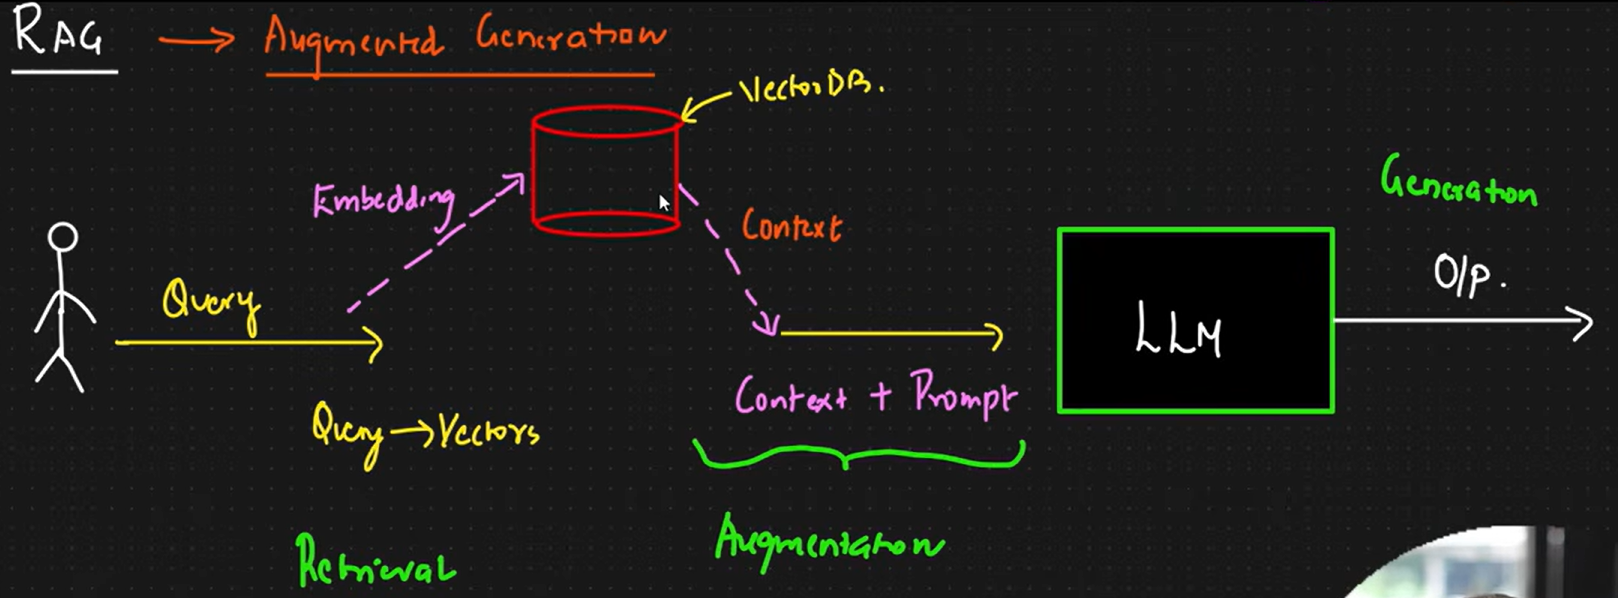

# Integration VectorDB Content Pipeline with LLM output

In [49]:
## Create simple RAG pipeline with groq llm

from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv()

### Initial Groq LLM (Set your GROQ_API_KEY in enviroment)

groq_api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(groq_api_key=groq_api_key, model_name = 'llama-3.3-70b-versatile', temperature=0.1,max_tokens=1024)

## 2. Simple RAG function: retrieve context + generate response

def rag_simple(query, retriever, llm, top_k=3):
    ## retriever the context
    results = retriever.retrieve(query, top_k=top_k)
    context="\n\n".join([doc['content'] for doc in results]) if results else ""
    if not context:
        return "No relevant context found to answer the question."
    
    ## generate the answwer using GROQ LLM
    prompt=f"""Use the following context to answer the question concisely.
        Context:
        {context}

        Question: {query}

        Answer:"""
        
    response = llm.invoke([prompt.format(context=context, query=query)])
    
    return response.content


In [50]:
answer=rag_simple("What is attention mechanism?",rag_retriever,llm)
print(answer)

Retrieving documents for query: 'What is attention mechanism?'
Top K: 3, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 29.13it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (after filtering)


An attention function that maps a query and a set of key-value pairs to an output, computing the output as a weighted sum of the values.


# Enhance RAG Pipeline

In [51]:
# --- Enhanced RAG Pipeline Features ---
def rag_advanced(query, retriever, llm, top_k=5, min_score=0.2, return_context=False):
    """
    RAG pipeline with extra features:
    - Returns answer, sources, confidence score, and optionally full context.
    """
    results = retriever.retrieve(query, top_k=top_k, score_threshold=min_score)
    if not results:
        return {'answer': 'No relevant context found.', 'sources': [], 'confidence': 0.0, 'context': ''}
    
    # Prepare context and sources
    context = "\n\n".join([doc['content'] for doc in results])
    sources = [{
        'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
        'page': doc['metadata'].get('page', 'unknown'),
        'score': doc['similarity_score'],
        'preview': doc['content'][:300] + '...'
    } for doc in results]
    confidence = max([doc['similarity_score'] for doc in results])
    
    # Generate answer
    prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {query}\n\nAnswer:"""
    response = llm.invoke([prompt.format(context=context, query=query)])
    
    output = {
        'answer': response.content,
        'sources': sources,
        'confidence': confidence
    }
    if return_context:
        output['context'] = context
    return output

# Example usage:
result = rag_advanced("Food Classification Techniques and Models", rag_retriever, llm, top_k=3, min_score=0.1, return_context=True)
print("Answer:", result['answer'])
print("Sources:", result['sources'])
print("Confidence:", result['confidence'])
print("Context Preview:", result['context'][:300])

Retrieving documents for query: 'Food Classification Techniques and Models'
Top K: 3, Score threshold: 0.1
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 11.73it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (after filtering)


Answer: The context mentions the following food classification techniques and models:

1. Random Decision Forests (Ho, 1995)
2. Feature Fusion (Hoashi et al., 2010)
3. Multiple Kernel Learning (Joutou and Yanai, 2009)
4. Convolutional Architecture for Fast Feature Embedding (Caffe, Jia, 2013)
5. Structural SVMs (Joachims et al., 2009)
6. Random Forest Component Mining (used in Food-101 dataset)
Sources: [{'source': 'food101.pdf', 'page': 14, 'score': 0.27400434017181396, 'preview': '14. Ho, T.K.: Random decision forests. In: ICDAR (1995)\n15. Hoashi, H., Joutou, T., Yanai, K.: Image Recognition of 85 Food Categories by\nFeature Fusion. In: ISM (2010)\n16. Jia, Y.: Caﬀe: An open source convolutional architecture for fast feature embed-\nding. http://caffe.berkeleyvision.org/ (2013)\n...'}, {'source': 'food101.pdf', 'page': 14, 'score': 0.27400434017181396, 'preview': '14. Ho, T.K.: Random decision forests. In: ICDAR (1995)\n15. Hoashi, H., Joutou, T., Yanai, K.: Image Recognition of 85 

In [53]:
# --- Advanced RAG Pipeline: Streaming, Citations, History, Summarization ---
from typing import List, Dict, Any
import time

class AdvancedRAGPipeline:
    def __init__(self, retriever, llm):
        self.retriever = retriever
        self.llm = llm
        self.history = []  # Store query history

    def query(self, question: str, top_k: int = 5, min_score: float = 0.2, stream: bool = False, summarize: bool = False) -> Dict[str, Any]:
        # Retrieve relevant documents
        results = self.retriever.retrieve(question, top_k=top_k, score_threshold=min_score)
        if not results:
            answer = "No relevant context found."
            sources = []
            context = ""
        else:
            context = "\n\n".join([doc['content'] for doc in results])
            sources = [{
                'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
                'page': doc['metadata'].get('page', 'unknown'),
                'score': doc['similarity_score'],
                'preview': doc['content'][:120] + '...'
            } for doc in results]
            # Streaming answer simulation
            prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {question}\n\nAnswer:"""
            if stream:
                print("Streaming answer:")
                for i in range(0, len(prompt), 80):
                    print(prompt[i:i+80], end='', flush=True)
                    time.sleep(0.05)
                print()
            response = self.llm.invoke([prompt.format(context=context, question=question)])
            answer = response.content

        # Add citations to answer
        citations = [f"[{i+1}] {src['source']} (page {src['page']})" for i, src in enumerate(sources)]
        answer_with_citations = answer + "\n\nCitations:\n" + "\n".join(citations) if citations else answer

        # Optionally summarize answer
        summary = None
        if summarize and answer:
            summary_prompt = f"Summarize the following answer in 2 sentences:\n{answer}"
            summary_resp = self.llm.invoke([summary_prompt])
            summary = summary_resp.content

        # Store query history
        self.history.append({
            'question': question,
            'answer': answer,
            'sources': sources,
            'summary': summary
        })

        return {
            'question': question,
            'answer': answer_with_citations,
            'sources': sources,
            'summary': summary,
            'history': self.history
        }

# Example usage:
adv_rag = AdvancedRAGPipeline(rag_retriever, llm)
result = adv_rag.query("what are object detection algorithms?", top_k=3, min_score=0.1, stream=True, summarize=True)
print("\nFinal Answer:", result['answer'])
print("Summary:", result['summary'])
print("History:", result['history'][-1])

Retrieving documents for query: 'what are object detection algorithms?'
Top K: 3, Score threshold: 0.1
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 24.27it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (after filtering)
Streaming answer:
Use the following context to answer the question concisely.
Context:
1) A review of classical computer vision techniques for
object detection.
2) An analysis of general region proposal generation tech-
niques.
3) A detailed review of convolution-based models for ob-
ject detection, including two-stage and one-stage det

ec-
tors.
The paper is organized as follows: Section 2 covers classical
computer vision techniques for object detection, Section 3
discusses region proposal generation, Section 4 explores CNN-
based detection architectures, Section 5 reviews applications,
Section 6 lists popular datasets, Section 7 covers evaluation
metrics, and Section 8 concludes with future directions.
II. CLASSICAL COMPUTER VISION TECHNIQUES
FOR OBJECT DETECTION
Earlier computer vision techniques for image processing,
particularly image similarity, relied on feature-based methods
arXiv:2412.05252v1  [cs.CV]  6 Dec 2024

1) A review of classical computer vision techniques for
object detection.
2) An analysis of general region proposal generation tech-
niques.
3) A detailed review of convolution-based models for ob-
ject detection, including two-stage and one-stage detec-
tors.
The paper is organized as follows: Section 2 covers classical
computer vision techniques for object detection, Section 3
discusses region pro